<a href="https://colab.research.google.com/github/tamnhu2913/Customer-Journey-Analysis/blob/main/User_Journey_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dowload dataset form Kaggle
The dataset was used in this project: E-Commerce Customer Journey: Click to Conversion

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sufya6/e-commerce-customer-journey-click-to-conversion")

print("Path to dataset files:", path)

import os
print(os.listdir(path))

Using Colab cache for faster access to the 'e-commerce-customer-journey-click-to-conversion' dataset.
Path to dataset files: /kaggle/input/e-commerce-customer-journey-click-to-conversion
['customer_journey.csv']


In [3]:
file_path = os.path.join(path, 'customer_journey.csv')

data_frame = pd.read_csv(file_path)
print(data_frame.head())

   SessionID     UserID            Timestamp      PageType DeviceType  \
0  session_0  user_2223  2025-01-20 22:53:34          home    Desktop   
1  session_1  user_2192  2025-02-26 12:57:10          home     Tablet   
2  session_1  user_2192  2025-02-26 12:59:11  product_page     Tablet   
3  session_2  user_1708  2025-06-24 15:40:46          home     Mobile   
4  session_3  user_2976  2025-06-11 07:21:02          home     Tablet   

   Country ReferralSource  TimeOnPage_seconds  ItemsInCart  Purchased  
0    India   Social Media                  55            0          0  
1  Germany          Email                  99            0          0  
2  Germany          Email                 121            0          0  
3    India         Google                 160            0          0  
4       UK         Google                 113            0          0  


#Check information of dataset and data cleaning

In [4]:
print("Shape of dataset: ", data_frame.shape)

Shape of dataset:  (12719, 10)


In [5]:
print('Column names of dataset: ')
print(data_frame.columns.values)

Column names of dataset: 
['SessionID' 'UserID' 'Timestamp' 'PageType' 'DeviceType' 'Country'
 'ReferralSource' 'TimeOnPage_seconds' 'ItemsInCart' 'Purchased']


In [6]:
print("Information of dataset: ")
print(data_frame.info())

Information of dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   SessionID           12719 non-null  object
 1   UserID              12719 non-null  object
 2   Timestamp           12719 non-null  object
 3   PageType            12719 non-null  object
 4   DeviceType          12719 non-null  object
 5   Country             12719 non-null  object
 6   ReferralSource      12719 non-null  object
 7   TimeOnPage_seconds  12719 non-null  int64 
 8   ItemsInCart         12719 non-null  int64 
 9   Purchased           12719 non-null  int64 
dtypes: int64(3), object(7)
memory usage: 993.8+ KB
None


In [7]:
print("Check the missing value")
print(data_frame.isnull().sum())

Check the missing value
SessionID             0
UserID                0
Timestamp             0
PageType              0
DeviceType            0
Country               0
ReferralSource        0
TimeOnPage_seconds    0
ItemsInCart           0
Purchased             0
dtype: int64


In [8]:
data_frame['Timestamp'] = pd.to_datetime(data_frame['Timestamp'], errors = 'coerce')
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12719 entries, 0 to 12718
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   SessionID           12719 non-null  object        
 1   UserID              12719 non-null  object        
 2   Timestamp           12719 non-null  datetime64[ns]
 3   PageType            12719 non-null  object        
 4   DeviceType          12719 non-null  object        
 5   Country             12719 non-null  object        
 6   ReferralSource      12719 non-null  object        
 7   TimeOnPage_seconds  12719 non-null  int64         
 8   ItemsInCart         12719 non-null  int64         
 9   Purchased           12719 non-null  int64         
dtypes: datetime64[ns](1), int64(3), object(6)
memory usage: 993.8+ KB


In [9]:
cols = ['PageType', 'DeviceType', 'Country', 'ReferralSource']
for col in cols:
    print(f'{col}:')
    print(data_frame[col].unique())
    print('-' * 40)

PageType:
['home' 'product_page' 'cart' 'checkout' 'confirmation']
----------------------------------------
DeviceType:
['Desktop' 'Tablet' 'Mobile']
----------------------------------------
Country:
['India' 'Germany' 'UK' 'France' 'Australia' 'USA' 'Canada']
----------------------------------------
ReferralSource:
['Social Media' 'Email' 'Google' 'Direct']
----------------------------------------


In [10]:
numeric_df = data_frame.select_dtypes(include=[np.number])
numeric_df.describe()

,TimeOnPage_seconds,ItemsInCart,Purchased
count,12719.000000,12719.000000,12719.000000
mean,97.427707,1.138533,0.397044
std,48.120729,1.689954,0.489304
min,15.000000,0.000000,0.000000
25%,56.000000,0.000000,0.000000
50%,98.000000,0.000000,0.000000
75%,139.000000,2.000000,1.000000
max,180.000000,5.000000,1.000000


In [11]:
print(data_frame[(data_frame['UserID']=='user_1002') & (data_frame['SessionID'] == 'session_2118')])

         SessionID     UserID           Timestamp      PageType DeviceType  \
5352  session_2118  user_1002 2025-06-10 07:24:03          home     Tablet   
5353  session_2118  user_1002 2025-06-10 07:26:37  product_page     Tablet   
5354  session_2118  user_1002 2025-06-10 07:29:35          cart     Tablet   
5355  session_2118  user_1002 2025-06-10 07:30:46      checkout     Tablet   
5356  session_2118  user_1002 2025-06-10 07:32:01  confirmation     Tablet   

      Country ReferralSource  TimeOnPage_seconds  ItemsInCart  Purchased  
5352  Germany   Social Media                 171            0          1  
5353  Germany   Social Media                 154            0          1  
5354  Germany   Social Media                 178            5          1  
5355  Germany   Social Media                  71            5          1  
5356  Germany   Social Media                  75            0          1  


In [12]:
SessionData = data_frame.groupby(['UserID','SessionID']).agg(
    Month = ('Timestamp', lambda x: x.min().month),
    Hour = ('Timestamp', lambda x: x.min().hour),
    Device = ('DeviceType', 'first'),
    Country = ('Country', 'first'),
    Source = ('ReferralSource', 'first'),
    ItemsInCart = ('ItemsInCart', 'max'),
    Purchased = ('Purchased', 'max'),
).reset_index()

PageTimeData = data_frame.pivot_table(
    index = ['UserID', 'SessionID'],
    columns = 'PageType',
    values = 'TimeOnPage_seconds',
    fill_value = 0
).reset_index()

SessionData = SessionData.merge(PageTimeData, on = ['UserID', 'SessionID'])
SessionData['Purchased'] = SessionData.pop('Purchased')
print(SessionData.head())

      UserID     SessionID  Month  Hour   Device  Country        Source  \
0  user_1001  session_2922      3     8  Desktop  Germany        Google   
1  user_1001  session_4102      2    15   Mobile   Canada         Email   
2  user_1002  session_2118      6     7   Tablet  Germany  Social Media   
3  user_1002  session_2943      5     7   Mobile   France         Email   
4  user_1004  session_1089      2     8   Tablet  Germany        Google   

   ItemsInCart   cart  checkout  confirmation   home  product_page  Purchased  
0            3   54.0     128.0         131.0   89.0          97.0          1  
1            3    0.0       0.0           0.0   30.0         122.0          0  
2            5  178.0      71.0          75.0  171.0         154.0          1  
3            0    0.0       0.0           0.0   25.0         111.0          0  
4            0    0.0       0.0           0.0   98.0           0.0          0  


In [13]:
print('Check null value:\n',SessionData.isnull().sum())

Check null value:
 UserID          0
SessionID       0
Month           0
Hour            0
Device          0
Country         0
Source          0
ItemsInCart     0
cart            0
checkout        0
confirmation    0
home            0
product_page    0
Purchased       0
dtype: int64


In [14]:
SessionData.to_csv('session_data.csv', index=False)
print('SessionData downloaded as session_data.csv')

SessionData downloaded as session_data.csv


# EDA

## Số lượng User và Session

In [15]:
print('So luong Session:', SessionData['SessionID'].count())

So luong Session: 5000


In [16]:
print('So luong User :', SessionData['UserID'].nunique())

So luong User : 1872


## Phân tích Journey của user

In [17]:
data_frame = data_frame.sort_values(by=['SessionID', 'Timestamp'])
journey_df = data_frame.groupby(['UserID', 'SessionID']).agg(
    PageType = ('PageType', lambda x: tuple(x))
).reset_index()

journey_df_count = pd.DataFrame({'Count': journey_df['PageType'].value_counts().sort_index()})
journey_df_count['Percentage'] = (journey_df_count['Count'] / journey_df_count['Count'].sum())*100
print('Number of each Journey:\n',journey_df_count)

Number of each Journey:
                                                     Count  Percentage
PageType                                                             
(home,)                                              1013       20.26
(home, product_page)                                 2388       47.76
(home, product_page, cart)                            476        9.52
(home, product_page, cart, checkout)                  113        2.26
(home, product_page, cart, checkout, confirmation)   1010       20.20


Thông qua kết quả thống kê trên ta thấy về cơ bản 1 hành trình của user sẽ gồm các bước sau:

\begin{align}
\text{home page } \rightarrow \text{product page } \rightarrow \text{cart page } \rightarrow \text{checkout page } \rightarrow \text{confirmation page }
\end{align}

Number of each Page:
               Count   DropRate
PageType                      
home           5000   0.000000
product_page   3987  20.260000
cart           1599  59.894658
checkout       1123  29.768605
confirmation   1010  10.062333


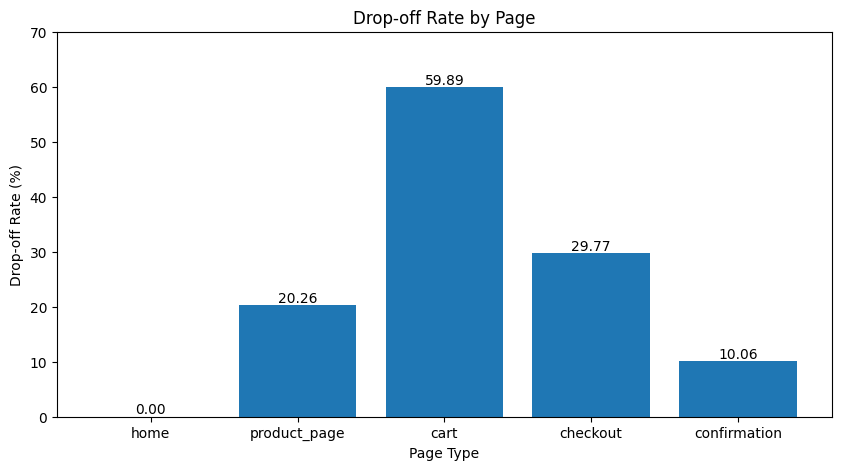

In [42]:
dropoff = pd.DataFrame({'Count': data_frame['PageType'].value_counts().sort_values(ascending=False)})
dropoff['DropRate'] = 100 * (dropoff['Count'].shift(1) - dropoff['Count'])/dropoff['Count'].shift(1)
dropoff = dropoff.fillna(0)
print('Number of each Page:\n',dropoff)
plt.figure(figsize = (10,5))
bar_container = plt.bar(dropoff.index, dropoff['DropRate'])
plt.title('Drop-off Rate by Page')
plt.xlabel('Page Type')
plt.ylabel('Drop-off Rate (%)')
plt.bar_label(bar_container, fmt='{:,.2f}')
plt.ylim(0,70)
plt.show()

In [19]:
dropoff.reset_index().to_csv(
    'dropoff_summary.csv',
    index=False
)

              Count   DropRate  TotalTime    AvgTime
PageType                                            
home           5000   0.000000   488954.0  97.790800
product_page   3987  20.260000   386967.0  97.057186
cart           1599  59.894658   157891.0  98.743590
checkout       1123  29.768605   108489.0  96.606411
confirmation   1010  10.062333    96882.0  95.922772


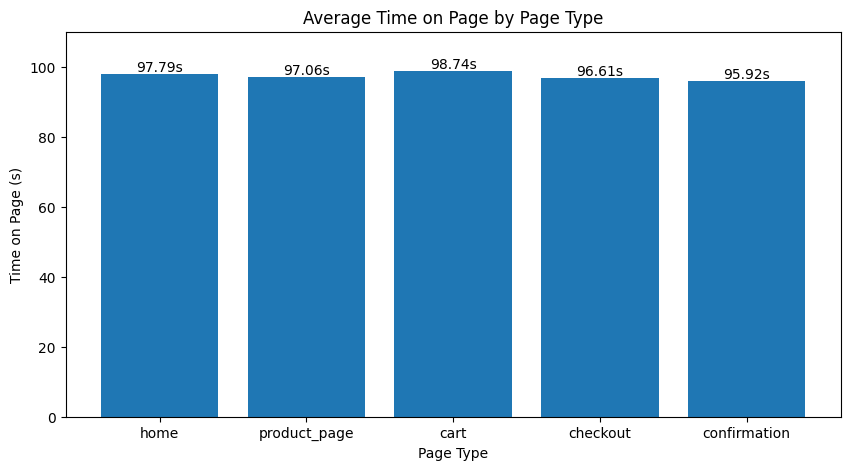

In [47]:
plt.figure(figsize = (10,5))

page_time_df = SessionData[['cart','checkout','confirmation','home','product_page']].copy()
dropoff['TotalTime'] = page_time_df.sum()
dropoff['AvgTime'] = dropoff['TotalTime'] / dropoff['Count']
print(dropoff)
bar_container = plt.bar(dropoff.index, dropoff['AvgTime'])
plt.xlabel('Page Type')
plt.ylabel('Time on Page (s)')
plt.title('Average Time on Page by Page Type')
plt.bar_label(bar_container, fmt='{:,.2f}s')
plt.ylim(0,110)
plt.show()

Thông qua việc phân tích tỷ lệ drop-off và thời gian trung bình người dùng dành cho từng Page Type, có thể thấy giai đoạn **Product Page → Cart Page** có tỷ lệ drop-off cao nhất, ở mức **59.89%**. Cụ thể, trong số những user đã truy cập **Product Page**, khoảng **59.89%** không tiếp tục chuyển sang **Cart Page**. Trong khi đó, thời gian trung bình trên **Product Page** là **97.06 giây**, cho thấy người dùng dành một khoảng thời gian tương đối đáng kể để tương tác với trang sản phẩm trước khi quyết định có tiếp tục hành trình hay không.

Kết quả này cho thấy **Product Page** là một điểm đáng chú ý trong hành trình người dùng, khi thời gian tương tác tương đối cao nhưng tỷ lệ chuyển tiếp sang **Cart Page** lại thấp. Tuy nhiên, chỉ từ các chỉ số drop-off và thời gian trung bình, chưa thể xác định chính xác nguyên nhân. Một số khả năng cần được kiểm tra thêm có thể bao gồm:

* Không có sản phẩm mà user cần
* Giá sản phẩm cao hơn budget của user
* Giao diện **Product Page** khó thao tác

Giải pháp được gợi ý: Thay đổi giao diện thân thiện hơn với người sử dụng. Đưa những sản phẩm có đánh giá tốt và giá thấp lên để thu hút sự chú ý của người tiêu dùng.

Khi người dùng đã bước tới và thêm sản phẩm vào giỏ hàng thì tỷ lệ rời đi giảm xuống đáng kể. **Tỷ lệ drop-off từ Cart → Checkout là 29.77%, trong khi từ Checkout → Confirmation chỉ còn 10.06%**. Điều này cho thấy phần lớn người dùng đã đi đến các bước cuối của quy trình có xu hướng tiếp tục hoàn tất hành trình.

Nhìn chung, tỷ lệ chuyển đổi của website là **20.20%** (vì theo mô tả của dataset khi tới bước Confirmation thì `purchased` luôn là 1). Phần lớn user rời đi ở giai đoạn đầu của session, đặc biệt là ở bước **Product Page → Cart**, với tỷ lệ drop-off lên tới **59.89%**. Do đó, cần tối ưu Product Page là một trong những ưu tiên quan trọng để cải thiện tỷ lệ chuyển đổi.


## Phân tích thời điểm mua hàng.

Session count by Month:
 Month    1    2    3    4    5    6    7    8
count  657  593  630  564  634  630  656  636
Session count by Hour:
 Hour    0    1    2    3    4    5    6    7    8    9    10   11   12   13   14   15   16   17   18   19   20   21   22   23
count  226  183  174  201  211  195  214  191  215  213  214  214  203  218  217  225  191  218  237  212  213  218  194  203


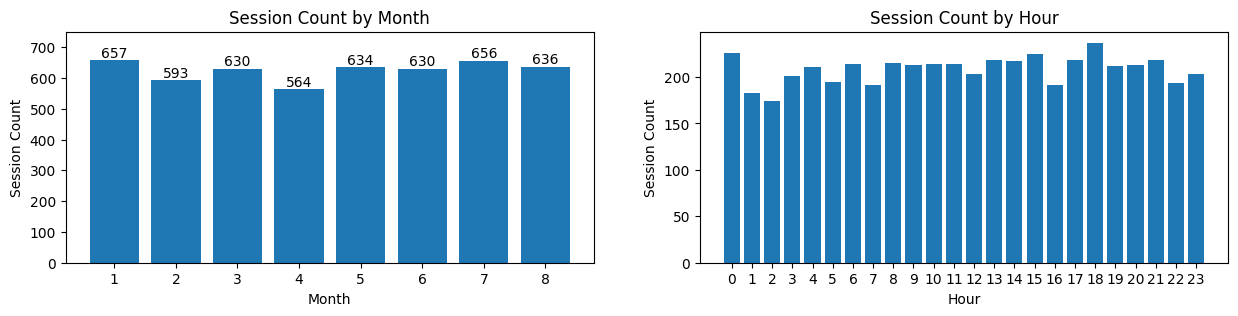

In [22]:
SessionByMonth = SessionData['Month'].value_counts().sort_index()
print('Session count by Month:\n', pd.DataFrame([SessionByMonth]).to_string())
plt.figure(figsize = (15,3))
plt.subplot(1,2,1)
BarCont = plt.bar(SessionByMonth.index.values, SessionByMonth.values)
plt.xlabel('Month')
plt.ylabel('Session Count')
plt.title('Session Count by Month')
plt.bar_label(BarCont, fmt='{:,.0f}')
plt.xticks(SessionByMonth.index.values)
plt.ylim([0,750])


SessionByHour = SessionData['Hour'].value_counts().sort_index()
print('Session count by Hour:\n',pd.DataFrame([SessionByHour]).to_string())
plt.subplot(1,2,2)
plt.bar(SessionByHour.index.values, SessionByHour.values)
plt.xlabel('Hour')
plt.ylabel('Session Count')
plt.title('Session Count by Hour')
plt.xticks(SessionByHour.index.values)
plt.show()

* **Traffic by Month:** Lượng truy cập giữa các tháng tương đối ổn định, dao động từ 564 đến 657 sessions. Tháng 1 ghi nhận số lượng session cao nhất (657), trong khi tháng 4 có lượng session thấp nhất (564). Mức chênh lệch giữa tháng cao nhất và thấp nhất không lớn, cho thấy lưu lượng truy cập được duy trì khá đồng đều trong suốt thời gian thu thập dữ liệu.

* **Traffic by Hour:** Lượng truy cập thấp nhất xuất hiện vào lúc 2h sáng với 174 sessions. Sau đó traffic tăng dần trong ngày và đạt đỉnh vào lúc 18h với 237 sessions. Điều này cho thấy người dùng có xu hướng truy cập website nhiều hơn vào cuối ngày. Ngoài ra, khoảng thời gian từ 8h đến 15h ghi nhận lượng truy cập tương đối ổn định, dao động quanh mức 200–225 sessions mỗi giờ, phản ánh lưu lượng truy cập đều đặn trong giờ hành chính.

In [23]:
MonthHour = SessionData.groupby(['Month', 'Hour']).size().unstack(fill_value=0)
print(MonthHour.head())
HourOver30 = (MonthHour >= 30).sum(axis = 1)
print(pd.DataFrame([HourOver30]).to_string())


Hour   0   1   2   3   4   5   6   7   8   9   ...  14  15  16  17  18  19  \
Month                                          ...                           
1      40  28  18  40  37  21  26  15  32  35  ...  35  28  19  29  22  23   
2      32  18  20  25  19  26  27  26  30  22  ...  30  29  15  23  35  26   
3      25  29  19  25  22  22  25  26  20  29  ...  31  36  26  25  33  27   
4      19  18  20  20  21  26  23  26  27  23  ...  27  24  25  35  24  19   
5      21  29  33  24  27  25  32  22  23  26  ...  23  23  23  28  29  38   

Hour   20  21  22  23  
Month                  
1      35  20  26  25  
2      26  33  16  36  
3      19  29  31  28  
4      21  23  22  19  
5      31  25  22  28  

[5 rows x 24 columns]
Month  1  2  3  4  5  6  7  8
0      8  6  4  2  5  6  7  6


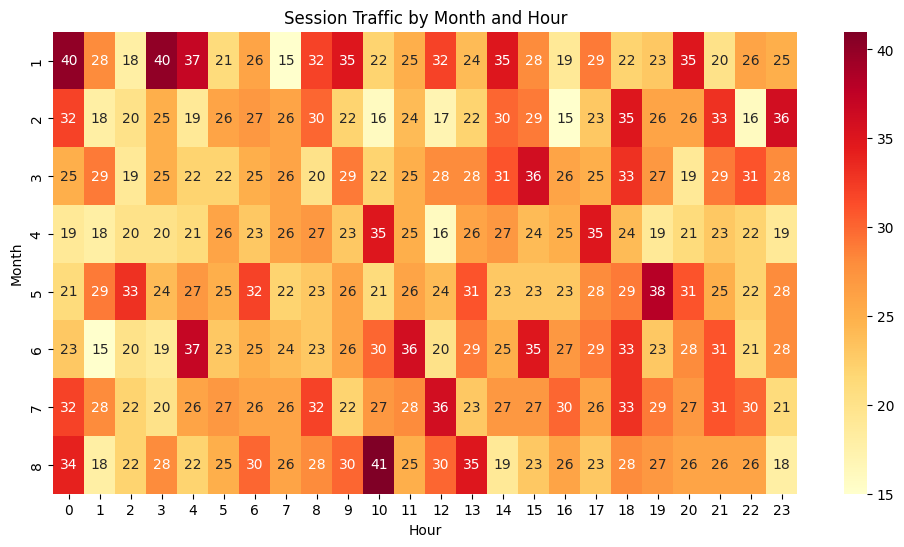

In [24]:
import seaborn as sns

plt.figure(figsize = (12,6))
sns.heatmap(MonthHour,
            annot = True,
            fmt = 'd',
            cmap = 'YlOrRd')
plt.title('Session Traffic by Month and Hour')
plt.xlabel('Hour')
plt.ylabel('Month')

plt.show()

Lưu lượng truy cập tương đối ổn định giữa các tháng và chưa cho thấy xu hướng mùa vụ rõ rệt. Traffic tập trung chủ yếu trong khoảng 10h–18h, trong khi 1h–3h sáng là thời điểm ít truy cập nhất. Mức traffic theo giờ cao nhất ghi nhận vào 10h tháng 8 (41 sessions). Ngoài ra, tháng 1 và tháng 7 có nhiều khung giờ traffic cao (≥30 sessions) nhất, trong khi tháng 4 có ít khung giờ traffic cao nhất, cho thấy mức độ tương tác thấp hơn các tháng còn lại.

## Phân tích số lượng Session theo Country, Device Type, Referral Source

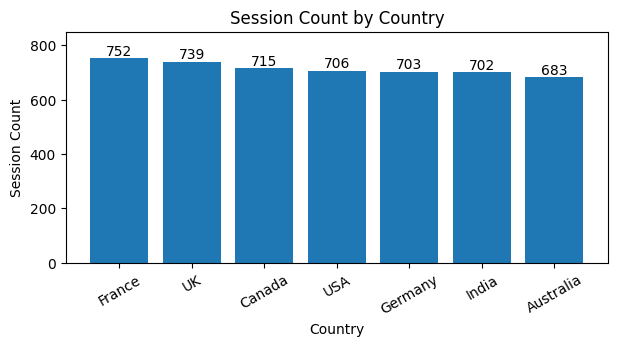

In [25]:
CountCountry = SessionData['Country'].value_counts()
plt.figure(figsize = (7,3))
bar_container = plt.bar(CountCountry.index.values, CountCountry.values)
plt.xlabel('Country')
plt.ylabel('Session Count')
plt.title('Session Count by Country')
plt.xticks(rotation = 30)
plt.bar_label(bar_container, fmt = "%d")
plt.ylim([0,850])
plt.show()

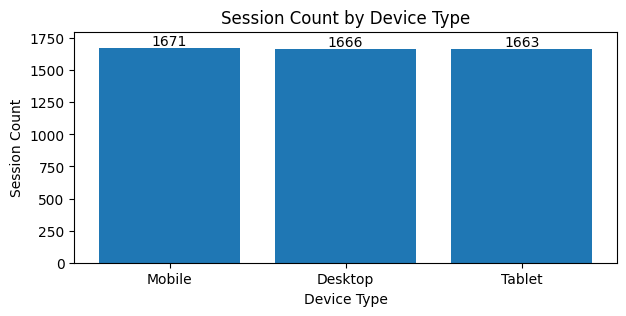

In [26]:
CountDevice = SessionData['Device'].value_counts()
plt.figure(figsize = (7,3))
bar_container = plt.bar(CountDevice.index.values, CountDevice.values)
plt.xlabel('Device Type')
plt.ylabel('Session Count')
plt.title('Session Count by Device Type')
plt.bar_label(bar_container, fmt = "%d")
plt.ylim([0,1800])
plt.show()

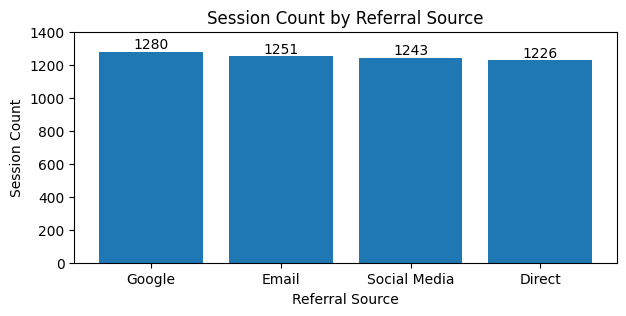

In [27]:
CountSource = SessionData['Source'].value_counts()
plt.figure(figsize = (7,3))
bar_container = plt.bar(CountSource.index.values, CountSource.values)
plt.xlabel('Referral Source')
plt.ylabel('Session Count')
plt.title('Session Count by Referral Source')
plt.bar_label(bar_container, fmt = "%d")
plt.ylim([0,1400])
plt.show()

* **Country:** Nhìn chung France có số lượng session cao nhất (752), theo sau là UK (739) và Canada (715). Số lượng truy cập của từng quốc gia không có sự chênh lệch nhiều, không có quốc gia nào chiếm tỷ lệ truy cập quá lớn so với các quốc gia khác.

* **Device Type:** Phân bố số lượng truy cập từ các thiết bị có sự đồng đều với Mobile (1671 session), Desktop (1666 session) và Tablet (1663). Không có thiết bị nào chiếm ưu thế về lưu lượng truy cập người dùng.

* **Referral Source:** Google chiếm traffic cao nhất (1280 session), theo sau là Email (1281 session), Social Media (1243) và Direct (1226). Việc thu hút lưu lượng truy cập có vẻ đa dạng trên nhiều kênh.

**KẾT LUẬN:** Số lượng session đồng đều trên Country, Device Type và Referral Source cho thấy user đa dạng và chiến lược thu hút khách hàng hiệu quả. Không có phân khúc nào chiếm ưu thế về lưu lượng truy cập, điều này cho thấy phạm bi tiếp cận của website ổn định và bền vững trên nhiều nhóm người dùng khác nhau.

## Tỉ lệ mua hàng chung (Conversion Analysis)

In [28]:
Buyed = SessionData[SessionData['Purchased'] == 1].copy()
rate = Buyed.shape[0] / SessionData.shape[0] * 100
print('So luong mua hang:', Buyed.shape[0] )
print('Ti le mua hang: {:.2f}%'.format(rate))

So luong mua hang: 1010
Ti le mua hang: 20.20%


Tỷ lệ mua hàng đạt 20.20%


# Tỉ lệ mua hàng theo Device Type, Country, Referall Source


           Total  Buyed       Rate
Country                           
France       752    170  22.606383
USA          706    147  20.821530
India        702    145  20.655271
UK           739    145  19.621110
Canada       715    140  19.580420
Australia    683    131  19.180088
Germany      703    132  18.776671


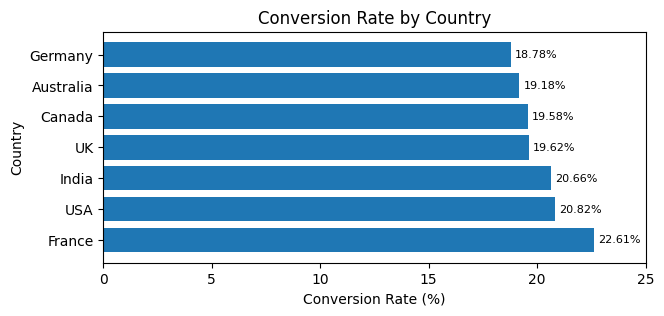

In [29]:
CountCountry = pd.DataFrame({
    'Total': CountCountry,
    'Buyed': Buyed.groupby('Country').size()
}).fillna(0)
CountCountry['Rate'] = CountCountry['Buyed'] / CountCountry['Total'] * 100
CountCountry = CountCountry.sort_values('Rate', ascending = False)
print(CountCountry)

plt.figure(figsize = (7,3))
container = plt.barh(CountCountry.index.values, CountCountry['Rate'])
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Country')
plt.title('Conversion Rate by Country')
plt.bar_label(container, fmt = '{:,.2f}%',fontsize = 8, padding = 3)
plt.xlim([0,25])
plt.show()

Nước Pháp có tỷ lệ chuyển mua hàng cao nhất với 22.61%, cao hơn tỷ lệ chuyển đổi chung (20.20%). Theo sao đó là USA và India với tỷ lệ lần lượt là 20.82% và 20.66%. Germany là nước có tỷ lể chuyển đổi thấp nhất (18.78%), nhưng mức độ chênh lệch giữa các quốc gia không đáng kể. Điều đó cho thấy hành vi mua hàng giữa các quốc gia có sự nhất quán.

         Total  Buyed       Rate
Device                          
Desktop   1666    339  20.348139
Mobile    1671    337  20.167564
Tablet    1663    334  20.084185


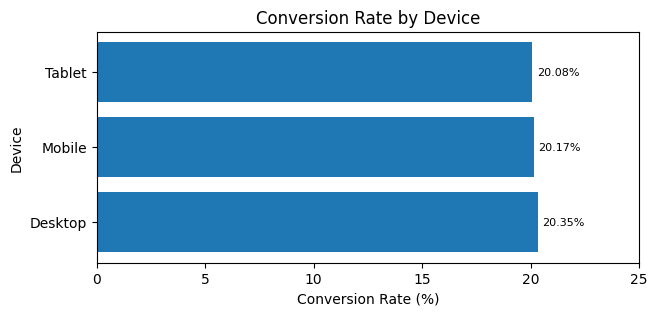

In [30]:
CountDevice = pd.DataFrame({
    'Total': CountDevice,
    'Buyed': Buyed.groupby('Device').size()
}).fillna(0)
CountDevice['Rate'] = CountDevice['Buyed'] / CountDevice['Total'] * 100
CountDevice = CountDevice.sort_values('Rate', ascending = False)
print(CountDevice)

plt.figure(figsize = (7,3))
container = plt.barh(CountDevice.index.values, CountDevice['Rate'])
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Device')
plt.title('Conversion Rate by Device')
plt.bar_label(container, fmt = '{:,.2f}%',fontsize = 8, padding = 3)
plt.xlim([0,25])
plt.show()

Chênh lẹch tỷ lệ chuyển đổi của các thiết bị không nhiều. Destop có tỷ lệ cao nhất với 20.35%, theo sau là Mobile với 20.17% và Tablet với 20.08%. Sự khác biệt giữa tỷ lệ cao nhất và thấp nhỏ hơn 0.3%, cho thấy trải nghiệm mua hàng giữa các thiết bị không phải là yếu tố ảnh hưởng tới hiệu suất chuyển đổi.

              Total  Buyed       Rate
Source                               
Google         1280    277  21.640625
Email          1251    251  20.063949
Direct         1226    243  19.820555
Social Media   1243    239  19.227675


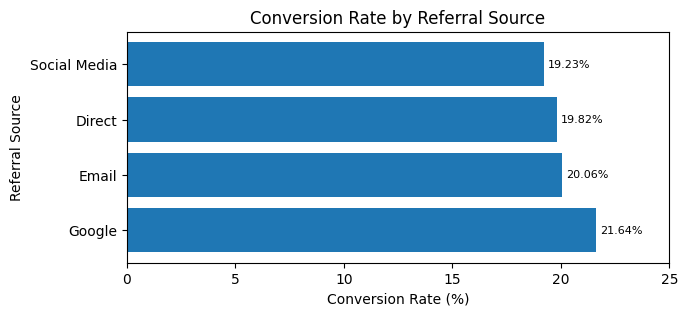

In [31]:
CountSource = pd.DataFrame({
    'Total' : CountSource,
    'Buyed': Buyed.groupby('Source').size()
}).fillna(0)
CountSource['Rate'] = CountSource['Buyed'] / CountSource['Total'] * 100
CountSource = CountSource.sort_values('Rate', ascending = False)
print(CountSource)

plt.figure(figsize = (7,3))
container = plt.barh(CountSource.index.values, CountSource['Rate'])
plt.xlabel('Conversion Rate (%)')
plt.ylabel('Referral Source')
plt.title('Conversion Rate by Referral Source')
plt.bar_label(container, fmt = '{:,.2f}%',fontsize = 8, padding = 3)
plt.xlim([0,25])
plt.show()

Google là kênh có tỷ lệ truy cập cao nhất với 21.64% và thấp nhất là Social Media với tỷ lệ 19.23%. Điều đó cho thấy khách truy cập đến từ công cụ tìm kiếm có ý định mua hàng nhiều hơn so với người dùng truy cập qua Socail Media hoặc Direct.

## Tỷ lệ chuyển đổi theo giờ và tháng

      Total  Buyed       Rate
Hour                         
0       226     51  22.566372
1       183     38  20.765027
2       174     34  19.540230
3       201     42  20.895522
4       211     38  18.009479
5       195     42  21.538462
6       214     32  14.953271
7       191     38  19.895288
8       215     41  19.069767
9       213     46  21.596244
10      214     37  17.289720
11      214     49  22.897196
12      203     44  21.674877
13      218     43  19.724771
14      217     44  20.276498
15      225     50  22.222222
16      191     42  21.989529
17      218     51  23.394495
18      237     48  20.253165
19      212     32  15.094340
20      213     48  22.535211
21      218     36  16.513761
22      194     41  21.134021
23      203     43  21.182266


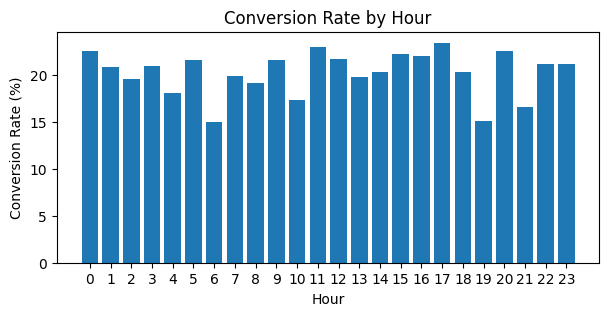

In [32]:
HourCount = pd.DataFrame({
    'Total': SessionByHour,
    'Buyed': Buyed.groupby('Hour').size()
}).fillna(0)
HourCount['Rate'] = HourCount['Buyed'] / HourCount['Total'] * 100
print(HourCount)
plt.figure(figsize = (7,3))
plt.bar(HourCount.index.values, HourCount['Rate'])
plt.xlabel('Hour')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Hour')
plt.xticks(HourCount.index.values)
plt.show()

Tỷ lệ chuyển đổi theo giờ dao động từ 14.95% đến 23.39%, cho thấy thời điểm truy cập có ảnh hưởng nhất định đến khả năng mua hàng. Các khung giờ 11h, 17h và 20h đạt tỷ lệ chuyển đổi cao nhất, trong khi 6h, 19h và 21h có hiệu quả thấp hơn. Điều này cho thấy thời gian truy cập có thể là một feature hữu ích trong mô hình dự đoán hành vi mua hàng.

       Total  Buyed       Rate
Month                         
1        657    126  19.178082
2        593    110  18.549747
3        630    135  21.428571
4        564    118  20.921986
5        634    129  20.347003
6        630    128  20.317460
7        656    133  20.274390
8        636    131  20.597484


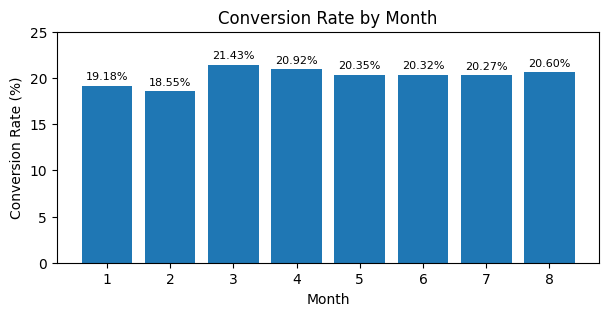

In [33]:
MonthCount = pd.DataFrame({
    'Total': SessionByMonth,
    'Buyed': Buyed.groupby('Month').size()
}).fillna(0)
MonthCount['Rate'] = MonthCount['Buyed'] / MonthCount['Total'] * 100
print(MonthCount)
plt.figure(figsize = (7,3))
container = plt.bar(MonthCount.index.values, MonthCount['Rate'])
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.title('Conversion Rate by Month')
plt.xticks(MonthCount.index.values)
plt.bar_label(container, fmt = '{:,.2f}%',fontsize = 8, padding = 3)
plt.ylim([0,25])
plt.show()

Tỷ lệ chuyển đổi có sự ổn định trong các tháng, di chuyển từ 18.55% cho tới 21.43%. Tháng 3 có tỷ lệ chuyển đổi cao nhất (21.43%), trong khi tháng 2 có tỷ lệ chuyển đổi thấp nhất (18.55%). Vì sự mức độ mua hàng giữa các tháng tương đối nhỏ nên không thấy rõ sự ảnh hưởng của yếu tố mùa vụ vào hành vi mua hàng của User.

## Tỷ lệ chuyển đổi theo thời gian trên page

In [34]:
# page_time_df = data_frame.pivot_table(
#     index = 'SessionID',
#     columns = 'PageType',
#     values = 'TimeOnPage_seconds',
#     fill_value = 0
# ).reset_index()
# page_time_df.columns.name = None
# page_time_df['Purchased'] = page_time_df['SessionID'].map(
#     PurchasedAnalysis.set_index('SessionID')['Purchased']
# )
# print('Number of Null value of Purchased variable: ',page_time_df['Purchased'].isna().sum())
# print(page_time_df.head())


In [35]:
# pages = ['home','product_page', 'cart', 'checkout','confirmation']
# for page in pages:
#   rate = page_time_df.loc[
#       page_time_df[page] > 0,
#       'Purchased'
#   ].mean() * 100
#   print(f'{page} : {rate:.2f}%')
#   # print(page_time_df.loc[page_time_df[page] > 0,'Purchased'])

In [36]:
pages = ['home','product_page', 'cart', 'checkout','confirmation']
for page in pages:
  rate = SessionData.loc[
      SessionData[page] > 0,
      'Purchased'
  ].mean() * 100
  print(f'{page} : {rate:.2f}%')

home : 20.20%
product_page : 25.33%
cart : 63.16%
checkout : 89.94%
confirmation : 100.00%


Tỷ lệ user đi qua page và có hàng tăng dần qua từng page, điều đó thể hiện cần vô sâu thì tỷ lệ mua hàng ngày càng cao.

In [37]:
bins = [0,30,60,90,120,180]
conversion_df = pd.DataFrame()

for page in pages:
  page_bins = pd.cut(SessionData[page], bins = bins)
  temp = SessionData.groupby(page_bins, observed=False)['Purchased'].mean() * 100
  conversion_df[page] = temp
conversion_df.index.name = 'bins'
print(conversion_df.head())


                 home  product_page       cart   checkout  confirmation
bins                                                                   
(0, 30]     20.350109     25.505051  56.375839  89.312977         100.0
(30, 60]    20.704846     26.455026  65.051903  89.690722         100.0
(60, 90]    20.562771     25.667656  62.633452  91.534392         100.0
(90, 120]   20.310766     26.151762  61.092150  90.783410         100.0
(120, 180]  19.668508     24.104006  65.247019  89.030612         100.0


In [38]:
print(SessionData['product_page'])

0        97.0
1       122.0
2       154.0
3       111.0
4         0.0
        ...  
4995    156.0
4996    125.0
4997    173.0
4998     73.0
4999    154.0
Name: product_page, Length: 5000, dtype: float64


In [39]:
bins = [0,30,60,90,120,180]
conversion_df = pd.DataFrame()

for page in pages:
  # print(page)
  page_bins = pd.cut(SessionData[page], bins = bins, include_lowest = True)
  # print(page_bins
  print(page_bins)
  temp = SessionData.groupby(page_bins, observed=False)['Purchased'].mean() * 100
  print(temp)
  # temp = page_time_df.groupby(page_bins, observed=False)['Purchased'].mean() * 100
  conversion_df[page] = temp
conversion_df.index.name = 'bins'
print(conversion_df.head())


0         (60.0, 90.0]
1       (-0.001, 30.0]
2       (120.0, 180.0]
3       (-0.001, 30.0]
4        (90.0, 120.0]
             ...      
4995     (90.0, 120.0]
4996      (30.0, 60.0]
4997      (30.0, 60.0]
4998    (-0.001, 30.0]
4999    (120.0, 180.0]
Name: home, Length: 5000, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 30.0] < (30.0, 60.0] < (60.0, 90.0] <
                                           (90.0, 120.0] < (120.0, 180.0]]
home
(-0.001, 30.0]    20.350109
(30.0, 60.0]      20.704846
(60.0, 90.0]      20.562771
(90.0, 120.0]     20.310766
(120.0, 180.0]    19.668508
Name: Purchased, dtype: float64
0        (90.0, 120.0]
1       (120.0, 180.0]
2       (120.0, 180.0]
3        (90.0, 120.0]
4       (-0.001, 30.0]
             ...      
4995    (120.0, 180.0]
4996    (120.0, 180.0]
4997    (120.0, 180.0]
4998      (60.0, 90.0]
4999    (120.0, 180.0]
Name: product_page, Length: 5000, dtype: category
Categories (5, interval[float64, right]): [(-0.001, 30.0] < 

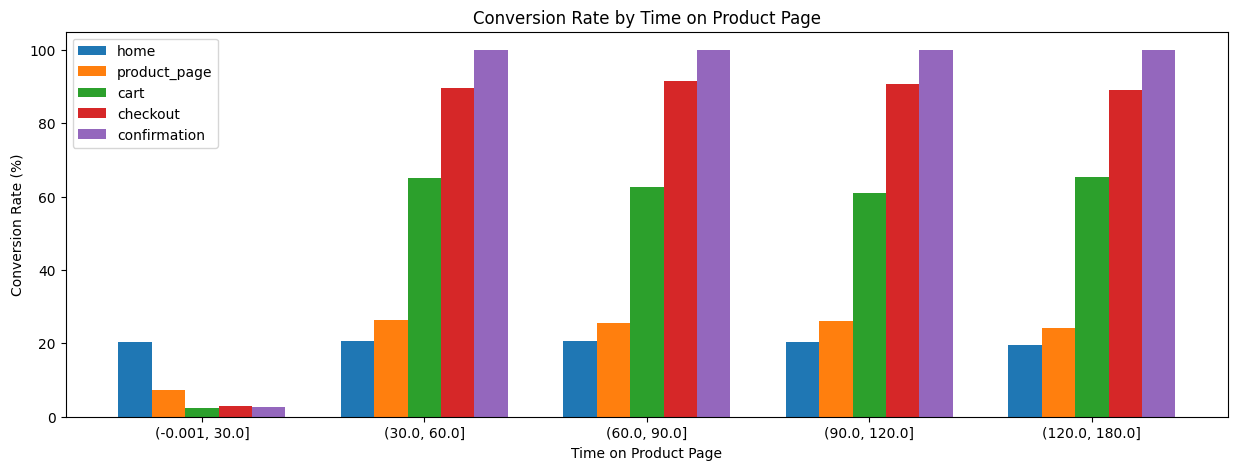

In [40]:
x = np.arange(len(conversion_df))
width = 0.15
plt.figure(figsize = (15,5))
for i, page in enumerate(conversion_df.columns):
  # if i > 2:
  #   break
  plt.bar(x + i * width, conversion_df[page], width = width, label = page)
plt.xticks(x + width * 2, conversion_df.index.astype(str))
plt.legend()
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Time on Product Page')
plt.title('Conversion Rate by Time on Product Page')
plt.show()

Tỷ lệ chuyển đổ ở từng page gần như ổn định:
* Với Page Home: Conversion dao động khoảng 20% và gần như không đổi giữa các khoảng thời gian
* Product Page: Dao động trong khoảng 24-26% , mức chênh lệch nhỏ
* Cart: Conversion cao hơn đáng kể (56-65%) nhưng cũng không tăng dần theo hời gian.
* Checkout: Luôn có mức độ duy trì cao, cho thấy User khi dến bước này có xác suất hoàn tất mua hàng rất lớn.
* Confirmation: Đây là bước cuối trong quá trình hoàn tất mua hàng vì vậy mọi session đến được page này đều đã mua hàng thành công.
Vì Conversion Rate không có sự khác biệt lớn giữa các nhóm thời gian trên cùng một page, cho nên có thể nói thời gian ở lại 1 page càng lâu thì cũng không phản ánh được quyết định mua hàng của User. Ngược lại, vị trí mà User đến từng page trong funnel lại phản ánh khả năng chuyển đổi rõ ràng hơn.

# Featuring